<a href="https://colab.research.google.com/github/ade2024606601005-collab/IMPLEMENTASI-MACHINE-LEARNING-UNTUK-DETEKSI-SPAM-EMAIL/blob/main/detection_spam_email_ade.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("spam_dataset_simulated.csv")

print("Jumlah data:", len(df))
print("\n5 data pertama:")
display(df.head())

print("\nDistribusi label:")
print(df["label"].value_counts())

Jumlah data: 1200

5 data pertama:


,label,message
0,ham,I will be late because of traffic.
1,ham,I have uploaded the presentation to the portal...
2,ham,Here is the updated meeting schedule.
3,spam,Lowest price guaranteed! Order now and save.
4,ham,Thank you for submitting the requested document.



Distribusi label:
label
ham     761
spam    439
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Mengubah label menjadi angka
df["label_num"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

# Membagi data 80% training dan 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    df["message"],
    df["label_num"],
    test_size=0.20,
    random_state=42,
    stratify=df["label_num"]
)

print("Data training:", len(X_train))
print("Data testing :", len(X_test))

Data training: 960
Data testing : 240


In [ ]:
# Membuat TF-IDF Vectorizer
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english"
)

# Training TF-IDF
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform data testing
X_test_tfidf = vectorizer.transform(X_test)

print("Jumlah fitur:", len(vectorizer.get_feature_names_out()))
print("Shape data training:", X_train_tfidf.shape)
print("Shape data testing :", X_test_tfidf.shape)

Jumlah fitur: 119
Shape data training: (960, 119)
Shape data testing : (240, 119)


In [ ]:
# Membuat model
model = MultinomialNB()

# Training
model.fit(X_train_tfidf, y_train)

print("Training model selesai!")

Training model selesai!


In [ ]:
# Prediksi data testing
y_pred = model.predict(X_test_tfidf)

# Menghitung evaluasi
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=== HASIL EVALUASI ===")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Ham", "Spam"]
))

=== HASIL EVALUASI ===
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

         Ham       1.00      1.00      1.00       152
        Spam       1.00      1.00      1.00        88

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



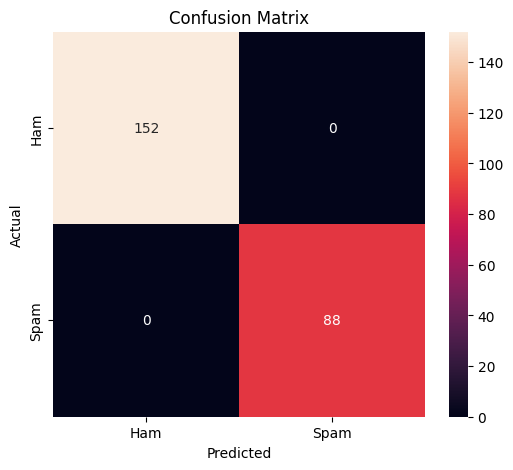

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
def predict_spam(message):
    x = vectorizer.transform([message])
    prediction = model.predict(x)[0]

    if prediction == 1:
        return "SPAM"
    else:
        return "BUKAN SPAM"

pesan = [
    "Congratulations! You won a free prize. Claim now!",
    "Halo, jangan lupa rapat kelompok besok jam 10.",
    "URGENT! You are selected for a cash reward. Click now.",
    "Please send me the assignment before 3 PM."
]

for msg in pesan:
    print("Pesan    :", msg)
    print("Prediksi :", predict_spam(msg))
    print("-" * 70)

Pesan    : Congratulations! You won a free prize. Claim now!
Prediksi : SPAM
----------------------------------------------------------------------
Pesan    : Halo, jangan lupa rapat kelompok besok jam 10.
Prediksi : BUKAN SPAM
----------------------------------------------------------------------
Pesan    : URGENT! You are selected for a cash reward. Click now.
Prediksi : SPAM
----------------------------------------------------------------------
Pesan    : Please send me the assignment before 3 PM.
Prediksi : BUKAN SPAM
----------------------------------------------------------------------


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

df = pd.read_csv("spam_dataset_simulated.csv")
df["label_num"] = df["label"].map({"ham": 0, "spam": 1})

X_train, X_test, y_train, y_test = train_test_split(
    df["message"], df["label_num"], test_size=0.20,
    random_state=42, stratify=df["label_num"]
)

vectorizer = TfidfVectorizer(lowercase=True, stop_words="english")
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = MultinomialNB()
model.fit(X_train_tfidf, y_train)
y_pred = model.predict(X_test_tfidf)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-Score :", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

def predict_spam(message):
    x = vectorizer.transform([message])
    return "SPAM" if model.predict(x)[0] == 1 else "BUKAN SPAM"

for msg in [
    "Congratulations! You won a free prize. Claim now!",
    "Halo, jangan lupa rapat kelompok besok jam 10.",
    "URGENT! You are selected for a cash reward. Click now.",
    "Please send me the assignment before 3 PM."
]:
    print("\nPesan:", msg)
    print("Prediksi:", predict_spam(msg))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-Score : 1.0
Confusion Matrix:
 [[152   0]
 [  0  88]]

Pesan: Congratulations! You won a free prize. Claim now!
Prediksi: SPAM

Pesan: Halo, jangan lupa rapat kelompok besok jam 10.
Prediksi: BUKAN SPAM

Pesan: URGENT! You are selected for a cash reward. Click now.
Prediksi: SPAM

Pesan: Please send me the assignment before 3 PM.
Prediksi: BUKAN SPAM
